# mT5 EDA 交互式演示 Notebook

这个 notebook 用于单条提示词演示，支持：

- 手动输入提示词
- 从 20 条备选提示词中选择一条
- 调用本地模型完成推理
- 解析模型输出 JSON
- 调用外部脚本生成图片
- 在 notebook 中直接展示图片

In [ ]:
# 如果环境里还没有依赖，可以先执行这一格

# %pip install transformers sentencepiece torch pillow

In [23]:
import importlib
import json
from pathlib import Path

from IPython.display import display
from PIL import Image

import scripts.render_schematic as render_schematic_module
import scripts.render_from_prediction as render_from_prediction_module
import scripts.run_inference_cpu as inference_module

# 每次运行 notebook 时主动重载外部脚本，避免继续使用旧版本模块缓存
importlib.reload(render_schematic_module)
importlib.reload(render_from_prediction_module)
importlib.reload(inference_module)

from scripts.run_inference_cpu import extract_json_object, validate_prediction, load_model, generate_text
from scripts.render_from_prediction import render_prediction_file

ROOT_DIR = Path.cwd()
MODEL_DIR = ROOT_DIR / 'models' / 'mt5-eda-generate'
RENDER_DIR = ROOT_DIR / 'renders' / 'notebook_interactive'

print('MODEL_DIR =', MODEL_DIR)
print('RENDER_DIR =', RENDER_DIR)

MODEL_DIR = c:\Users\34619\Desktop\Interview\EdaGenerate\models\mt5-eda-generate
RENDER_DIR = c:\Users\34619\Desktop\Interview\EdaGenerate\renders\notebook_interactive


In [24]:
# 20 条备选提示词

BACKUP_PROMPTS = [
    '设计一个完成 LED 指示功能的 EDA 原理图，包含电源 VCC、电阻 R1、LED LED1 和接地 GND。请给出所有节点的坐标以及节点之间的连接关系。',
    '请生成一个用于实现 LED 指示的基础原理图，电路节点包括电源 VDD、电阻 R1、LED LED1 和接地 GND。请输出标准字典格式的节点与边信息，并包含坐标。',
    '设计一个完成 RC 低通滤波功能的 EDA 原理图，包含输入 VIN、电阻 R1、输出 OUT、电容 C1 和接地 GND。请给出所有节点的坐标以及节点之间的连接关系。',
    '构建一个简单的 RC 低通滤波电路，要求使用输入 SIG_IN、电阻 R1、输出 VOUT、电容 C1 和接地 GND。请返回带有节点坐标和 edge 连接关系的结构化结果。',
    '给出一个实现 RC 低通滤波的原理图样本，节点包括输入 INPUT、电阻 RLP1、输出 OUTPUT、电容 CLP1 和接地 GND。请输出标准化的 components 和 edges 数据，并标明坐标。',
    '设计一个完成 RC 高通滤波功能的 EDA 原理图，包含输入 VIN、电容 C1、输出 OUT、电阻 R1 和接地 GND。请给出所有节点的坐标以及节点之间的连接关系。',
    '请生成一个用于实现 RC 高通滤波的基础原理图，电路节点包括输入 SIG_IN、电容 C_HP、输出 VOUT、电阻 R_HP 和接地 GND。请输出标准字典格式的节点与边信息，并包含坐标。',
    '设计一个完成 LC 滤波功能的 EDA 原理图，包含电源 VIN、电感 L1、输出 OUT、电容 C1 和接地 GND。请给出所有节点的坐标以及节点之间的连接关系。',
    '构建一个简单的 LC 滤波电路，要求使用电源 VCC、电感 L_FILTER、输出 VOUT、电容 C_FILTER 和接地 GND。请返回带有节点坐标和 edge 连接关系的结构化结果。',
    '设计一个完成电源去耦功能的 EDA 原理图，包含电源 VCC、负载 LOAD、电容 C1 和接地 GND。请给出所有节点的坐标以及节点之间的连接关系。',
    '请生成一个用于实现电源去耦的基础原理图，电路节点包括电源 VDD、负载 U_LOAD、电容 C_DECOUPLE 和接地 GND。请输出标准字典格式的节点与边信息，并包含坐标。',
    '设计一个完成电阻分压功能的 EDA 原理图，包含电源 VCC、电阻 R1、中间节点 MID、电阻 R2、接地 GND 和输出 OUT。请给出所有节点的坐标以及节点之间的连接关系。',
    '构建一个简单的电阻分压电路，要求使用电源 VIN、电阻 R_TOP、中间节点 MID、电阻 R_BOTTOM、接地 GND 和输出 VOUT。请返回带有节点坐标和 edge 连接关系的结构化结果。',
    '设计一个完成上拉按键输入功能的 EDA 原理图，包含电源 VCC、电阻 R1、中间节点 KEY_IN、按键 KEY1、接地 GND 和输出 OUT。请给出所有节点的坐标以及节点之间的连接关系。',
    '请生成一个用于实现上拉按键输入的基础原理图，电路节点包括电源 VDD、电阻 R_PULLUP、中间节点 BTN_NODE、按键 BTN1、接地 GND 和输出 SIG_OUT。请输出标准字典格式的节点与边信息，并包含坐标。',
    '设计一个完成下拉按键输入功能的 EDA 原理图，包含电源 VCC、按键 KEY1、中间节点 KEY_IN、电阻 R1、接地 GND 和输出 OUT。请给出所有节点的坐标以及节点之间的连接关系。',
    '构建一个简单的下拉按键输入电路，要求使用电源 VDD、按键 BTN1、中间节点 BTN_NODE、电阻 R_PULLDOWN、接地 GND 和输出 SIG_OUT。请返回带有节点坐标和 edge 连接关系的结构化结果。',
    '设计一个完成二极管防反接功能的 EDA 原理图，包含电源 VIN、二极管 D1、输出 VOUT、负载 LOAD 和接地 GND。请给出所有节点的坐标以及节点之间的连接关系。',
    '请生成一个用于实现二极管防反接的基础原理图，电路节点包括电源 PWR_IN、二极管 D_PROTECT、输出 PWR_SAFE、负载 U_LOAD 和接地 GND。请输出标准字典格式的节点与边信息，并包含坐标。',
    '设计一个完成简单整流滤波功能的 EDA 原理图，包含输入 AC_IN、二极管 D_RECT、输出 DC_OUT、电容 C_FILTER、负载 RL 和接地 GND。请给出所有节点的坐标以及节点之间的连接关系。'
]

print('备选提示词数量 =', len(BACKUP_PROMPTS))

备选提示词数量 = 20


In [25]:
# 查看 20 条备选提示词

for idx, prompt in enumerate(BACKUP_PROMPTS, start=1):
    print(f'{idx:02d}. {prompt}')

01. 设计一个完成 LED 指示功能的 EDA 原理图，包含电源 VCC、电阻 R1、LED LED1 和接地 GND。请给出所有节点的坐标以及节点之间的连接关系。
02. 请生成一个用于实现 LED 指示的基础原理图，电路节点包括电源 VDD、电阻 R1、LED LED1 和接地 GND。请输出标准字典格式的节点与边信息，并包含坐标。
03. 设计一个完成 RC 低通滤波功能的 EDA 原理图，包含输入 VIN、电阻 R1、输出 OUT、电容 C1 和接地 GND。请给出所有节点的坐标以及节点之间的连接关系。
04. 构建一个简单的 RC 低通滤波电路，要求使用输入 SIG_IN、电阻 R1、输出 VOUT、电容 C1 和接地 GND。请返回带有节点坐标和 edge 连接关系的结构化结果。
05. 给出一个实现 RC 低通滤波的原理图样本，节点包括输入 INPUT、电阻 RLP1、输出 OUTPUT、电容 CLP1 和接地 GND。请输出标准化的 components 和 edges 数据，并标明坐标。
06. 设计一个完成 RC 高通滤波功能的 EDA 原理图，包含输入 VIN、电容 C1、输出 OUT、电阻 R1 和接地 GND。请给出所有节点的坐标以及节点之间的连接关系。
07. 请生成一个用于实现 RC 高通滤波的基础原理图，电路节点包括输入 SIG_IN、电容 C_HP、输出 VOUT、电阻 R_HP 和接地 GND。请输出标准字典格式的节点与边信息，并包含坐标。
08. 设计一个完成 LC 滤波功能的 EDA 原理图，包含电源 VIN、电感 L1、输出 OUT、电容 C1 和接地 GND。请给出所有节点的坐标以及节点之间的连接关系。
09. 构建一个简单的 LC 滤波电路，要求使用电源 VCC、电感 L_FILTER、输出 VOUT、电容 C_FILTER 和接地 GND。请返回带有节点坐标和 edge 连接关系的结构化结果。
10. 设计一个完成电源去耦功能的 EDA 原理图，包含电源 VCC、负载 LOAD、电容 C1 和接地 GND。请给出所有节点的坐标以及节点之间的连接关系。
11. 请生成一个用于实现电源去耦的基础原理图，电路节点包括电源 VDD、负载 U_LOAD、电容 C_DECOUPLE 和接地 GND。请输出标准字典格式的节点与边信

In [26]:
# 加载模型

tokenizer, model = load_model(MODEL_DIR)
print('模型加载完成')

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


模型加载完成


In [51]:
# 这里手动输入提示词
# 如果 USER_PROMPT 为空，则自动使用 SELECTED_BACKUP_INDEX 指定的备选提示词

USER_PROMPT = '请生成一个用于实现 LED 指示的基础原理图，电路节点包括电源 VDD、电阻 R1、LED LED1 和接地 GND。请输出标准字典格式的节点与边信息，并包含坐标。'
SELECTED_BACKUP_INDEX =15

if USER_PROMPT.strip():
    FINAL_PROMPT = USER_PROMPT.strip()
else:
    FINAL_PROMPT = BACKUP_PROMPTS[SELECTED_BACKUP_INDEX - 1]

print('当前用于推理的提示词:')
print(FINAL_PROMPT)

当前用于推理的提示词:
请生成一个用于实现 LED 指示的基础原理图，电路节点包括电源 VDD、电阻 R1、LED LED1 和接地 GND。请输出标准字典格式的节点与边信息，并包含坐标。


{"function":"LED指示","layout_type":"chain_horizontal_mirrored","components":{"VDD":{"type":"power","x":20,"y":30},"R1":{"type":"resistor","x":50,"y":30},"LED1":{"type":"led","x":80,"y":30},"GND":{"type":"ground","x":100,"y":30}},"edges":{"edge1":["VDD","R1"],"edge2":["R1","LED1"],"edge3":["LED1","GND"]}}
valid = True
message = ok
c:\Users\34619\Desktop\Interview\EdaGenerate\renders\notebook_interactive\interactive_result.png


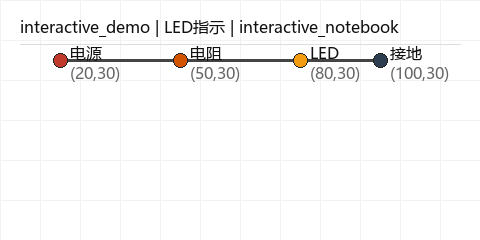

{
  "function": "LED指示",
  "layout_type": "chain_horizontal_mirrored",
  "components": {
    "VDD": {
      "type": "power",
      "x": 20,
      "y": 30
    },
    "R1": {
      "type": "resistor",
      "x": 50,
      "y": 30
    },
    "LED1": {
      "type": "led",
      "x": 80,
      "y": 30
    },
    "GND": {
      "type": "ground",
      "x": 100,
      "y": 30
    }
  },
  "edges": {
    "edge1": [
      "VDD",
      "R1"
    ],
    "edge2": [
      "R1",
      "LED1"
    ],
    "edge3": [
      "LED1",
      "GND"
    ]
  }
}


In [52]:
# 执行推理

raw_output = generate_text(
    tokenizer=tokenizer,
    model=model,
    prompt=FINAL_PROMPT,
    max_input_length=192,
    max_target_length=256,
    num_beams=1,
    do_sample=False,
    temperature=1.0,
)

print(raw_output)

# 解析输出并做结构校验

parsed_output = extract_json_object(raw_output)

if parsed_output is None:
    raise ValueError('模型输出不是合法 JSON，无法继续渲染图片。')

is_valid, message = validate_prediction(parsed_output)
print('valid =', is_valid)
print('message =', message)

if not is_valid:
    raise ValueError(f'模型输出结构不合法: {message}')

# 调用外部脚本对应的函数渲染图片，并保存到本地

RENDER_DIR.mkdir(parents=True, exist_ok=True)
image_path = RENDER_DIR / 'interactive_result.png'

render_prediction_file(
    prediction=parsed_output,
    prompt=FINAL_PROMPT,
    output_path=image_path,
    sample_id='interactive_demo',
    source_template_id='interactive_notebook',
)

print(image_path)
display(Image.open(image_path))
print(json.dumps(parsed_output, ensure_ascii=False, indent=2))